In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score,ConfusionMatrixDisplay,RocCurveDisplay

import joblib

In [21]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

In [22]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [26]:
print("Shape : ",df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape :  (10000, 14)

Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Data Types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [28]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [31]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [32]:
print("Duplicate rows : ", df.duplicated().sum())

Duplicate rows :  0


In [33]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (10000, 14)


In [36]:
print(df["Machine failure"].value_counts())

print("\nPercentage:")
print(df["Machine failure"].value_counts(normalize=True) * 100)

Machine failure
0    9661
1     339
Name: count, dtype: int64

Percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


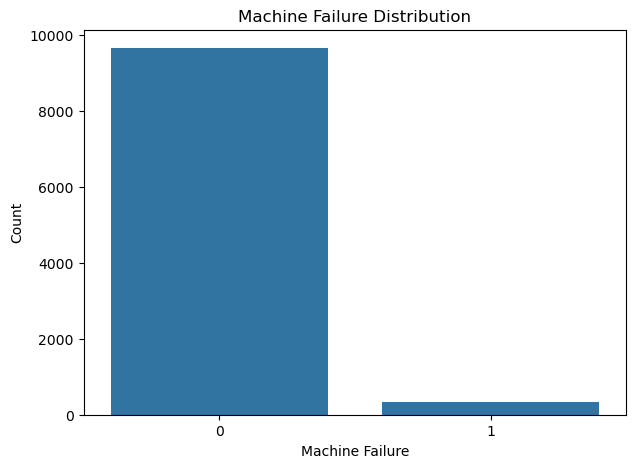

In [37]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Machine failure"
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

In [38]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [44]:
failure_columns = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

df[df[failure_columns] == 1].sum()

UDI                          0.0
Product ID                     0
Type                           0
Air temperature [K]          0.0
Process temperature [K]      0.0
Rotational speed [rpm]       0.0
Torque [Nm]                  0.0
Tool wear [min]              0.0
Machine failure              0.0
TWF                         46.0
HDF                        115.0
PWF                         95.0
OSF                         98.0
RNF                         19.0
dtype: object

In [42]:
failure_columns = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

df[failure_columns].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

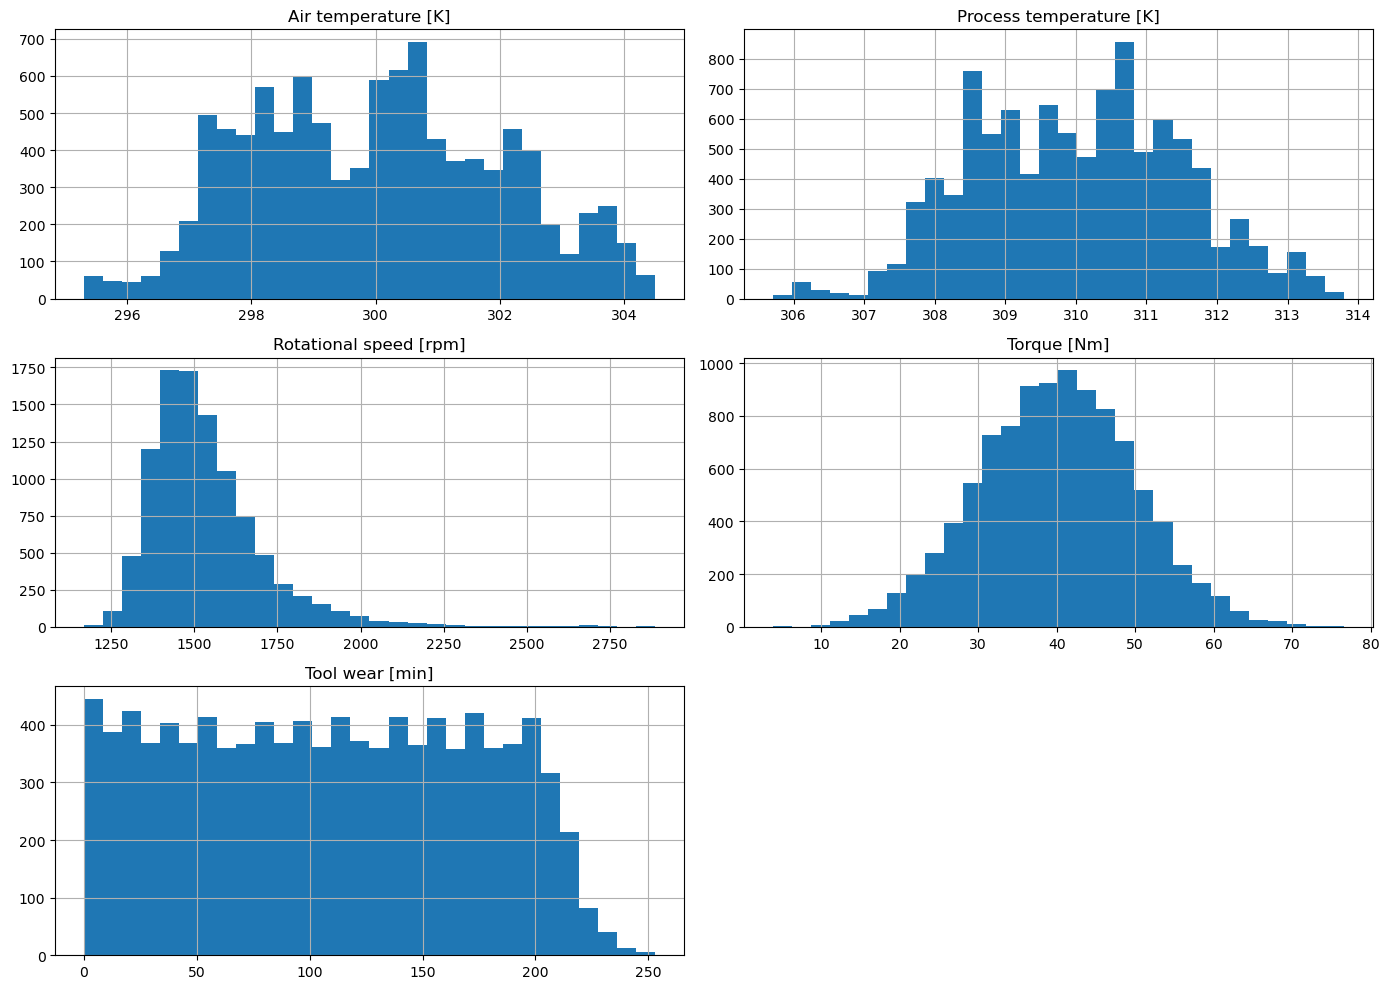

In [45]:
numeric_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[numeric_columns].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

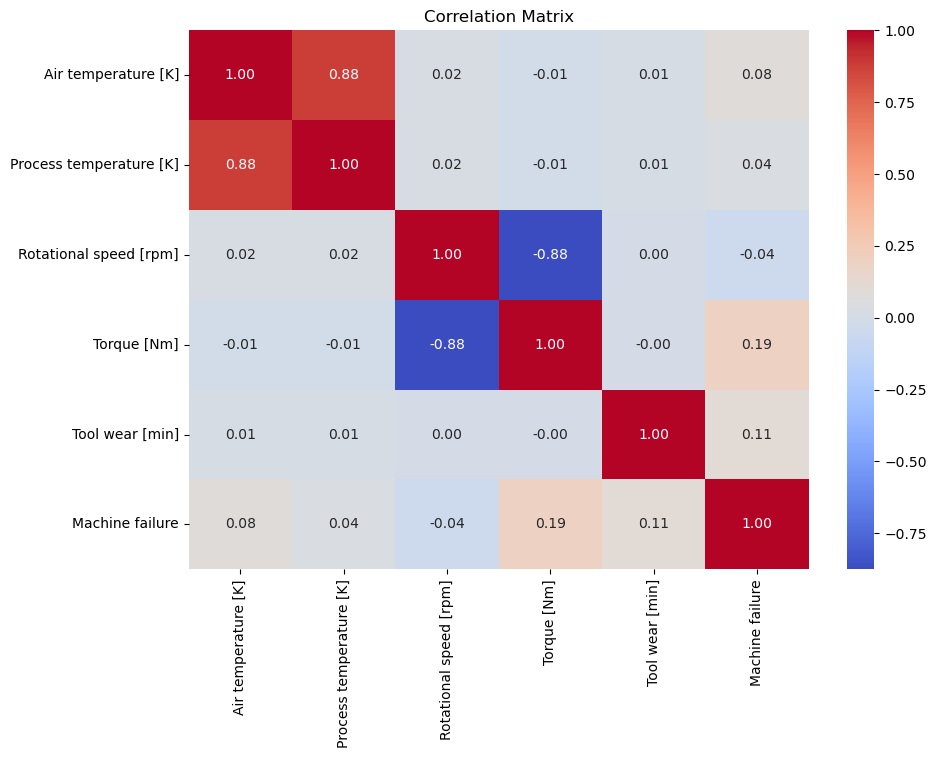

In [46]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_columns + ["Machine failure"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [47]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

target = "Machine failure"

In [48]:
X = df[features]
y = df[target]

In [55]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (10000, 6)
y shape: (10000,)

Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Target:
Machine failure


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [61]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [68]:
categorical_features = [
    "Type"
]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [69]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy='median')),
        ("scalar", StandardScaler())
    ]
) 

In [70]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [71]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",numeric_transformer,numerical_features),
        ("cat",categorical_transformer,categorical_features)
    ]
)

In [72]:
model = LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)

In [73]:
pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",model)
    ]
)

In [75]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Type'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [76]:
y_pred = pipeline.predict(X_test)

In [86]:
y_probability = pipeline.predict_proba(X_test)[:,1]

In [87]:
y_probability

array([0.97135024, 0.5379081 , 0.68019628, ..., 0.14890765, 0.59522328,
       0.01710193])

In [88]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8245


In [89]:
precision = precision_score(y_test,y_pred)

print("Precision:", precision)

Precision: 0.14177215189873418


In [90]:
recall = recall_score(y_test,y_pred)

print("Recall:", recall)

Recall: 0.8235294117647058


In [93]:
f1 = f1_score(y_test,y_pred)

print("F1 Score:", f1)

F1 Score: 0.24190064794816415


In [94]:
roc_auc = roc_auc_score(y_test,y_probability)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9069540859822189


In [95]:
print("===== MODEL PERFORMANCE =====")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

===== MODEL PERFORMANCE =====
Accuracy : 0.8245
Precision: 0.1418
Recall   : 0.8235
F1 Score : 0.2419
ROC-AUC  : 0.9070


In [96]:
print(classification_report(y_test,y_pred,target_names=[ "No Failure",
            "Machine Failure"]))

                 precision    recall  f1-score   support

     No Failure       0.99      0.82      0.90      1932
Machine Failure       0.14      0.82      0.24        68

       accuracy                           0.82      2000
      macro avg       0.57      0.82      0.57      2000
   weighted avg       0.96      0.82      0.88      2000



In [97]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[1593  339]
 [  12   56]]


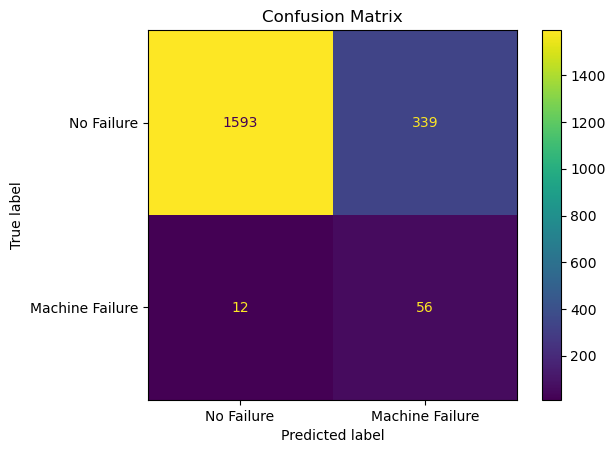

In [98]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Failure",
        "Machine Failure"
    ]
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

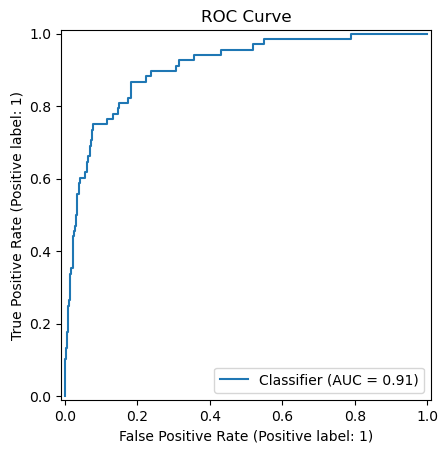

In [99]:
RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("ROC Curve")

plt.show()

In [100]:
machine = pd.DataFrame([
    {
        "Type": "M",
        "Air temperature [K]": 298.1,
        "Process temperature [K]": 308.6,
        "Rotational speed [rpm]": 1551,
        "Torque [Nm]": 42.8,
        "Tool wear [min]": 0
    }
])

In [103]:
prediction = pipeline.predict(machine)[0]

probability = pipeline.predict_proba(machine)[0][1]

print("Prediction:", prediction)
print("Failure Probability:", probability)

Prediction: 0
Failure Probability: 0.04933744974719851


In [104]:
if prediction == 1:
    result = "Machine Failure"
else:
    result = "No Machine Failure"

print(result)

No Machine Failure


In [107]:
joblib.dump(pipeline,"../data/model/machine_failure_pipeline.pkl")

['../data/model/machine_failure_pipeline.pkl']